In [1]:
import pandas as pd
import numpy as np
import random

In [2]:
df = pd.read_csv(
    "rideflow_feature_engineered.csv"
)

print(df.head())

      ride_id  pickup_zone  drop_zone  pickup_lat  pickup_long   drop_lat  \
0   95.247911            1          0   12.880239    80.148410  13.028939   
1  439.187633            4          5   13.092441    80.165458  13.142711   
2  876.685389            1          5   12.817965    80.161839  12.943527   
3  275.337197            4          6   13.125103    80.143306  13.209127   
4  106.743950            5          5   13.143513    80.302596  13.078330   

   drop_long    driver_id  customer_id  fare_price  ...  actual_eta_min  \
0  80.163941  1842.701958  6072.494896  450.514728  ...       18.304775   
1  80.149376  1186.296422  5942.228896  483.889094  ...       13.343961   
2  80.166040  1297.199801  5829.181415  382.581291  ...       12.039878   
3  80.126008  1765.474261  5429.619496  246.018489  ...        7.535792   
4  80.189672  1565.653849  5079.081677  270.302221  ...       12.104096   

   ride_status  traffic_level  weather  driver_active  hour  month  weekday  \
0      

In [ ]:
#CREATE DRIVER DATABASE

In [3]:
num_drivers = 500

In [ ]:
#GENERATE DRIVER DETAILS

In [4]:
driver_data = pd.DataFrame({

    "driver_id": np.arange(
        1000,
        1000 + num_drivers
    ),

    "driver_rating": np.random.uniform(
        3.0,
        5.0,
        num_drivers
    ),

    "eta": np.random.randint(
        2,
        20,
        num_drivers
    ),

    "cancellation_risk": np.random.uniform(
        0,
        1,
        num_drivers
    ),

    "availability": np.random.choice(
        [0, 1],
        num_drivers,
        p=[0.2, 0.8]
    )
})

In [ ]:
#CHECK DRIVER DATA

In [5]:
print(driver_data.head())

   driver_id  driver_rating  eta  cancellation_risk  availability
0       1000       4.365231   13           0.852729             1
1       1001       4.149026    7           0.005273             1
2       1002       3.997179   14           0.035025             1
3       1003       4.689864   10           0.977362             0
4       1004       3.913916   10           0.371904             1


In [ ]:
#CREATE AI MATCHING SCORE

Logic:

✅ higher rating = better
✅ lower ETA = better
✅ lower cancellation risk = better

In [ ]:
#MATCHING FORMULA

In [6]:
driver_data["matching_score"] = (

    (driver_data["driver_rating"] * 0.5)

    +

    (
        (1 / (driver_data["eta"] + 1)) * 10
    )

    +

    (
        (1 - driver_data["cancellation_risk"]) * 5
    )
)

In [ ]:
#FILTER AVAILABLE DRIVERS

In [7]:
available_drivers = driver_data[

    driver_data["availability"] == 1
]

In [ ]:
#SORT BEST DRIVERS

In [8]:
recommended_drivers = available_drivers.sort_values(

    by="matching_score",

    ascending=False
)

In [ ]:
#TOP DRIVER RECOMMENDATION

In [9]:
best_driver = recommended_drivers.iloc[0]

print(best_driver)

driver_id            1102.000000
driver_rating           4.834394
eta                     2.000000
cancellation_risk       0.026102
availability            1.000000
matching_score         10.620020
Name: 102, dtype: float64


In [ ]:
#DISPLAY RECOMMENDATION

In [10]:
print("\n🚖 Recommended Driver")

print(
    "Driver ID:",
    best_driver["driver_id"]
)

print(
    "Driver Rating:",
    round(
        best_driver["driver_rating"],
        2
    )
)

print(
    "ETA:",
    best_driver["eta"],
    "minutes"
)

print(
    "Cancellation Risk:",
    round(
        best_driver["cancellation_risk"],
        2
    )
)

print(
    "Matching Score:",
    round(
        best_driver["matching_score"],
        2
    )
)


🚖 Recommended Driver
Driver ID: 1102.0
Driver Rating: 4.83
ETA: 2.0 minutes
Cancellation Risk: 0.03
Matching Score: 10.62


In [ ]:
#GENERATE AI EXPLANATION

In [11]:
reason = f"""

Recommended because:

✔ High driver rating

✔ Low ETA

✔ Low cancellation risk

✔ Best overall matching score
"""

print(reason)



Recommended because:

✔ High driver rating

✔ Low ETA

✔ Low cancellation risk

✔ Best overall matching score



In [ ]:
#TOP 10 DRIVERS

In [12]:
print(
    recommended_drivers.head(10)
)

     driver_id  driver_rating  eta  cancellation_risk  availability  \
102       1102       4.834394    2           0.026102             1   
161       1161       4.371629    2           0.046690             1   
198       1198       4.740514    2           0.199595             1   
461       1461       4.792999    2           0.232381             1   
275       1275       3.785572    3           0.020459             1   
84        1084       3.335363    2           0.146939             1   
197       1197       3.944056    3           0.042721             1   
196       1196       3.611853    3           0.013703             1   
213       1213       4.972488    5           0.001292             1   
374       1374       3.958014    2           0.265344             1   

     matching_score  
102       10.620020  
161       10.285698  
198        9.705616  
461        9.567929  
275        9.290492  
84         9.266318  
197        9.258422  
196        9.237414  
213        9.146451 

In [ ]:
#VISUALIZE BEST DRIVERS

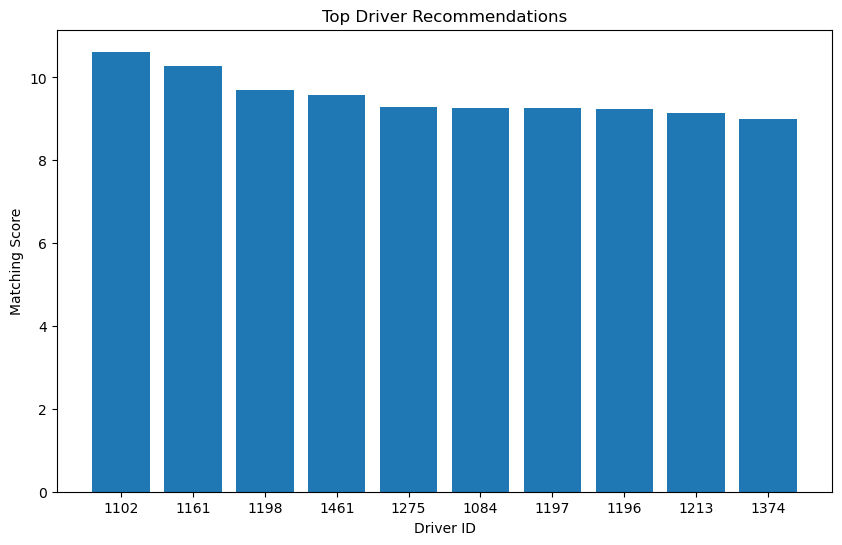

In [13]:
import matplotlib.pyplot as plt

top10 = recommended_drivers.head(10)

plt.figure(figsize=(10,6))

plt.bar(

    top10["driver_id"].astype(str),

    top10["matching_score"]
)

plt.title(
    "Top Driver Recommendations"
)

plt.xlabel("Driver ID")

plt.ylabel("Matching Score")

plt.show()

In [ ]:
#SAVE RECOMMENDATION DATA

In [14]:
recommended_drivers.to_csv(

    "recommended_drivers.csv",

    index=False
)

print(
    "Recommendation Data Saved"
)

Recommendation Data Saved


In [ ]:
#SAVE ASSISTANT LOGIC DATA

In [15]:
import joblib

joblib.dump(

    recommended_drivers,

    "ride_matching_assistant.pkl"
)

print(
    "Ride Matching Assistant Saved"
)

Ride Matching Assistant Saved
